# 1. Imports & dependencies 
#### Loads pandas, numpy, matplotlib, scipy, scikit-learn, pathlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.linear_model import LinearRegression
from pathlib import Path

# 2. File configuration 
#### Keep csv file in the same folder, change the file name here.

In [2]:
import os
base_dir = os.getcwd()
CSV_FILE = os.path.join(base_dir, "MIP_data.csv")

# 3. Parse multi-cycle CV export 
#### reads the UTF-16 file, locates the V,µA header, and splits it into one DataFrame per cycle.

In [3]:
def parse_cv_csv(filepath: str):
    """
    Reads the multi-cycle CV export.
    Returns a dict  {cycle_label: DataFrame(V [V], I [µA])}
    """
    with open(filepath, "r", encoding="utf-16") as fh:
        lines = fh.readlines()

    # Locate the unit-header row. Strip surrounding quotes first so this matches
    # whether or not the exporter wraps each line in double quotes
    # (before_2.csv is quoted, MIP2.csv is not).
    header_idx = next(
        (i for i, ln in enumerate(lines)
         if ln.strip().strip('"').startswith("V,")),
        None,
    )
    if header_idx is None:
        raise ValueError(
            "Could not locate the 'V,µA,...' unit-header row — "
            "check the file encoding and that this is a CV export."
        )

    # Two rows above the unit header are the cycle names
    cycle_name_line = lines[header_idx - 2].strip().strip('"')
    cycle_names_raw = [x.strip() for x in cycle_name_line.split(",")]
    cycle_names = [n for n in cycle_names_raw if n]  # drop empty separators
    n_cycles = len(cycle_names)
    print(f"Found {n_cycles} cycle(s):")
    for nm in cycle_names:
        print(f"  · {nm}")

    # Parse numeric data (every row after the unit header)
    data_lines = lines[header_idx + 1:]
    rows = []
    for ln in data_lines:
        vals = ln.strip().strip('"').split(",")
        rows.append([v.strip() for v in vals])

    raw = pd.DataFrame(rows)

    cycles = {}
    for k, name in enumerate(cycle_names):
        col_v = k * 2
        col_i = k * 2 + 1
        if col_i >= raw.shape[1]:
            break
        chunk = raw[[col_v, col_i]].copy()
        chunk.columns = ["V", "I"]
        chunk = chunk[chunk["V"].str.strip() != ""].dropna()
        chunk["V"] = pd.to_numeric(chunk["V"], errors="coerce")
        chunk["I"] = pd.to_numeric(chunk["I"], errors="coerce")
        chunk = chunk.dropna().reset_index(drop=True)
        cycles[name] = chunk
    return cycles


cycles_raw = parse_cv_csv(CSV_FILE)
print(f"\nPoints per cycle: {[len(v) for v in cycles_raw.values()]}")

Found 3 cycle(s):
  · Cyclic Voltammetry [2]: CV i vs E Scan 4 [2]
  · Cyclic Voltammetry [2]: CV i vs E Scan 5 [2]
  · Cyclic Voltammetry [2]: CV i vs E Scan 6 [2]

Points per cycle: [800, 800, 800]


# 4. Extract oxidation (anodic) sweep 

In [4]:
def extract_oxidation_sweep(df: pd.DataFrame):
    """
    Splits the full CV cycle at the voltage turning point and returns
    the ascending (anodic / oxidation) portion, sorted by V.
    """
    v = df["V"].values
    diffs = np.diff(v)
    sign_changes = np.where(np.diff(np.sign(diffs)))[0]

    if len(sign_changes) == 0:
        # No turning point found — return whole curve (edge case)
        return df.copy()

    # First turning point separates forward from reverse scan
    turn_idx = sign_changes[0] + 1
    forward = df.iloc[:turn_idx + 1].copy()

    # Keep only if it is the ascending half (positive dV trend)
    if forward["V"].iloc[-1] > forward["V"].iloc[0]:
        return forward.reset_index(drop=True)
    else:
        # Some instruments export reverse first; return the other half
        reverse = df.iloc[turn_idx + 1:].copy()
        return reverse.sort_values("V").reset_index(drop=True)


cycles_ox = {}
for name, df in cycles_raw.items():
    ox = extract_oxidation_sweep(df)
    cycles_ox[name] = ox
    print(f"{name}: {len(ox)} points  |  V [{ox['V'].min():.3f} → {ox['V'].max():.3f}]  "
          f"|  I_max = {ox['I'].max():.2f} µA")

Cyclic Voltammetry [2]: CV i vs E Scan 4 [2]: 401 points  |  V [-0.200 → 0.200]  |  I_max = 156.37 µA
Cyclic Voltammetry [2]: CV i vs E Scan 5 [2]: 401 points  |  V [-0.200 → 0.200]  |  I_max = 156.64 µA
Cyclic Voltammetry [2]: CV i vs E Scan 6 [2]: 401 points  |  V [-0.200 → 0.200]  |  I_max = 156.21 µA


# 5. Auto baseline finder (kept for reference, not used)
#### sliding-window regression for the most linear pre-peak region.

# 6. Baseline fit & peak current
#### fixed-window baseline (−0.15 → 0.00 V), peak detection, and ΔI above baseline per cycle.

In [5]:
results = {}

for name, df in cycles_ox.items():
    x = df["V"].values
    y = df["I"].values

    # ── Baseline (fixed region) ───────────────────────────────────────────────
    BASELINE_V_START = -0.15
    BASELINE_V_END   =  0.00
    mask = (x >= BASELINE_V_START) & (x <= BASELINE_V_END)
    slope, intercept, r_value, _, _ = stats.linregress(x[mask], y[mask])
    r2 = r_value**2
    x_start, x_end = BASELINE_V_START, BASELINE_V_END

    # ── Peak (maximum current point) ─────────────────────────────────────────
    peak_idx = np.argmax(y)
    peak_V   = x[peak_idx]
    peak_I   = y[peak_idx]

    # Baseline value at the peak voltage
    baseline_at_peak = slope * peak_V + intercept
    peak_current     = peak_I - baseline_at_peak   # µA above baseline

    results[name] = dict(
        df        = df,
        x         = x,
        y         = y,
        slope     = slope,
        intercept = intercept,
        x_start   = x_start,
        x_end     = x_end,
        r2        = r2,
        peak_V    = peak_V,
        peak_I    = peak_I,
        baseline_at_peak = baseline_at_peak,
        peak_current     = peak_current,
    )

    print(f"\n{'─'*60}")
    print(f"Cycle : {name}")
    print(f"  Baseline : Y = {slope:.4f}·X + {intercept:.4f}   (R² = {r2:.5f})")
    print(f"  Baseline range : {x_start:.4f} → {x_end:.4f} V")
    print(f"  Peak   : V = {peak_V:.4f} V,  I = {peak_I:.4f} µA")
    print(f"  Peak current (above baseline) : {peak_current:.4f} µA")


────────────────────────────────────────────────────────────
Cycle : Cyclic Voltammetry [2]: CV i vs E Scan 4 [2]
  Baseline : Y = 19.1367·X + 1.2537   (R² = 0.99255)
  Baseline range : -0.1500 → 0.0000 V
  Peak   : V = 0.0580 V,  I = 156.3680 µA
  Peak current (above baseline) : 154.0037 µA

────────────────────────────────────────────────────────────
Cycle : Cyclic Voltammetry [2]: CV i vs E Scan 5 [2]
  Baseline : Y = 18.4762·X + 1.1615   (R² = 0.99290)
  Baseline range : -0.1500 → 0.0000 V
  Peak   : V = 0.0570 V,  I = 156.6430 µA
  Peak current (above baseline) : 154.4278 µA

────────────────────────────────────────────────────────────
Cycle : Cyclic Voltammetry [2]: CV i vs E Scan 6 [2]
  Baseline : Y = 18.1710·X + 1.1480   (R² = 0.99252)
  Baseline range : -0.1500 → 0.0000 V
  Peak   : V = 0.0570 V,  I = 156.2060 µA
  Peak current (above baseline) : 154.0217 µA


# 7. Plot sweeps with baseline & peak
#### per-cycle CV plots with baseline line, fit window, peak marker, and ΔI arrow; saves cv_oxidation_peaks.png.

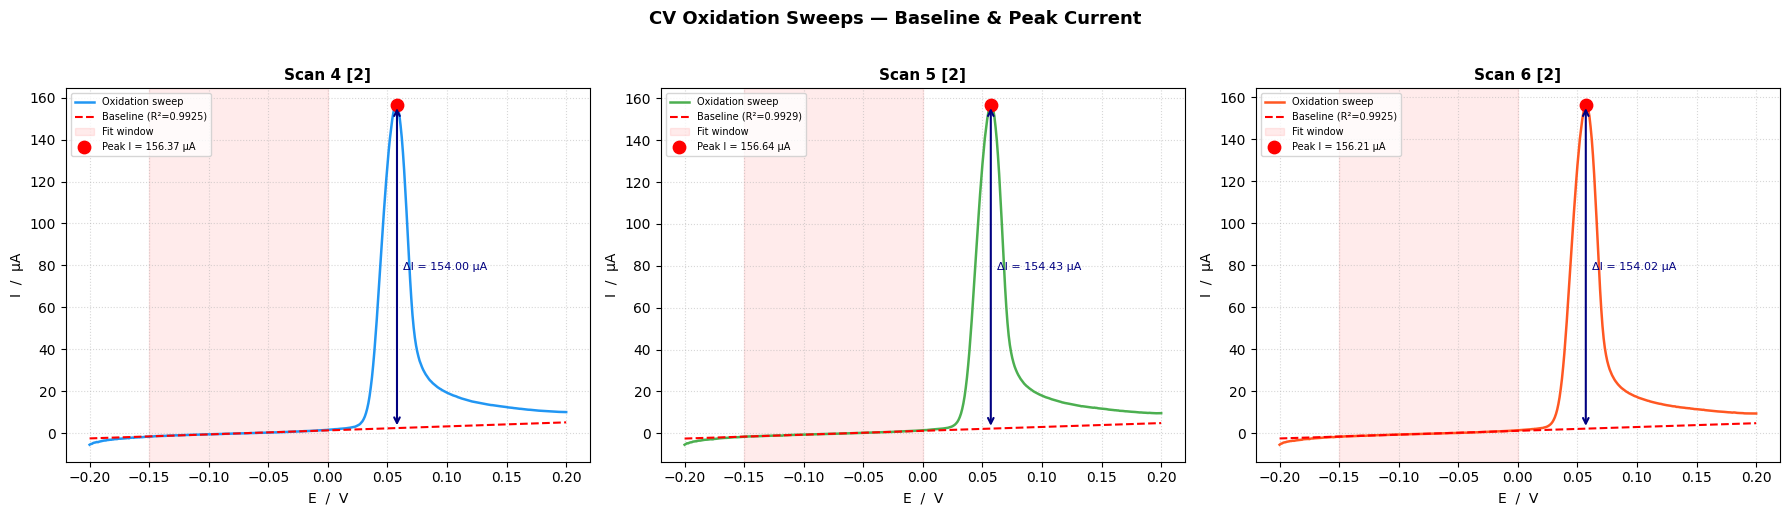

Figure saved → cv_oxidation_peaks.png


In [6]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

COLORS = ["#2196F3", "#4CAF50", "#FF5722", "#9C27B0", "#FF9800"]

for ax, (name, r), color in zip(axes, results.items(), COLORS):
    x, y = r["x"], r["y"]

    # ── CV oxidation curve ───────────────────────────────────────────────────
    ax.plot(x, y, color=color, lw=1.8, label="Oxidation sweep", zorder=2)

    # ── Baseline extended across the full V range ────────────────────────────
    x_line = np.linspace(x.min(), x.max(), 300)
    y_line = r["slope"] * x_line + r["intercept"]
    ax.plot(x_line, y_line, "r--", lw=1.5, label=f"Baseline (R²={r['r2']:.4f})", zorder=3)

    # Highlight the fitted baseline region
    ax.axvspan(r["x_start"], r["x_end"], alpha=0.08, color="red", label="Fit window")

    # ── Peak marker ──────────────────────────────────────────────────────────
    ax.scatter([r["peak_V"]], [r["peak_I"]], s=80, color="red",
               zorder=5, label=f"Peak I = {r['peak_I']:.2f} µA")

    # ── Distance arrow (peak → baseline) ─────────────────────────────────────
    ax.annotate(
        "",
        xy    = (r["peak_V"], r["baseline_at_peak"]),
        xytext= (r["peak_V"], r["peak_I"]),
        arrowprops=dict(arrowstyle="<->", color="navy", lw=1.5),
        zorder=6,
    )
    mid_y = (r["peak_I"] + r["baseline_at_peak"]) / 2
    ax.text(
        r["peak_V"] + 0.005, mid_y,
        f"ΔI = {r['peak_current']:.2f} µA",
        fontsize=8, color="navy", va="center",
    )

    # ── Labels ───────────────────────────────────────────────────────────────
    # Use only scan number as short title
    short = name.split("Scan")[-1].strip() if "Scan" in name else name
    ax.set_title(f"Scan {short}", fontsize=11, fontweight="bold")
    ax.set_xlabel("E  /  V", fontsize=10)
    ax.set_ylabel("I  /  µA", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("CV Oxidation Sweeps — Baseline & Peak Current", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cv_oxidation_peaks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → cv_oxidation_peaks.png")

# 8. Summary table & export
#### builds the results DataFrame and writes cv_peak_summary.csv.

In [7]:
summary = pd.DataFrame([
    {
        "Cycle"              : name,
        "Peak V (V)"         : round(r["peak_V"], 4),
        "Peak I (µA)"        : round(r["peak_I"], 4),
        "Baseline slope"     : round(r["slope"], 6),
        "Baseline intercept" : round(r["intercept"], 6),
        "Baseline R²"        : round(r["r2"], 5),
        "ΔI_peak (µA)"       : round(r["peak_current"], 4),
    }
    for name, r in results.items()
])

display(summary)
summary.to_csv("cv_peak_summary.csv", index=False)
print("Summary saved → cv_peak_summary.csv")

,Cycle,Peak V (V),Peak I (µA),Baseline slope,Baseline intercept,Baseline R²,ΔI_peak (µA)
0,Cyclic Voltammetry [2]: CV i vs E Scan 4 [2],0.058,156.368,19.136731,1.253718,0.99255,154.0037
1,Cyclic Voltammetry [2]: CV i vs E Scan 5 [2],0.057,156.643,18.476185,1.161485,0.99290,154.4278
2,Cyclic Voltammetry [2]: CV i vs E Scan 6 [2],0.057,156.206,18.170976,1.147991,0.99252,154.0217


Summary saved → cv_peak_summary.csv
